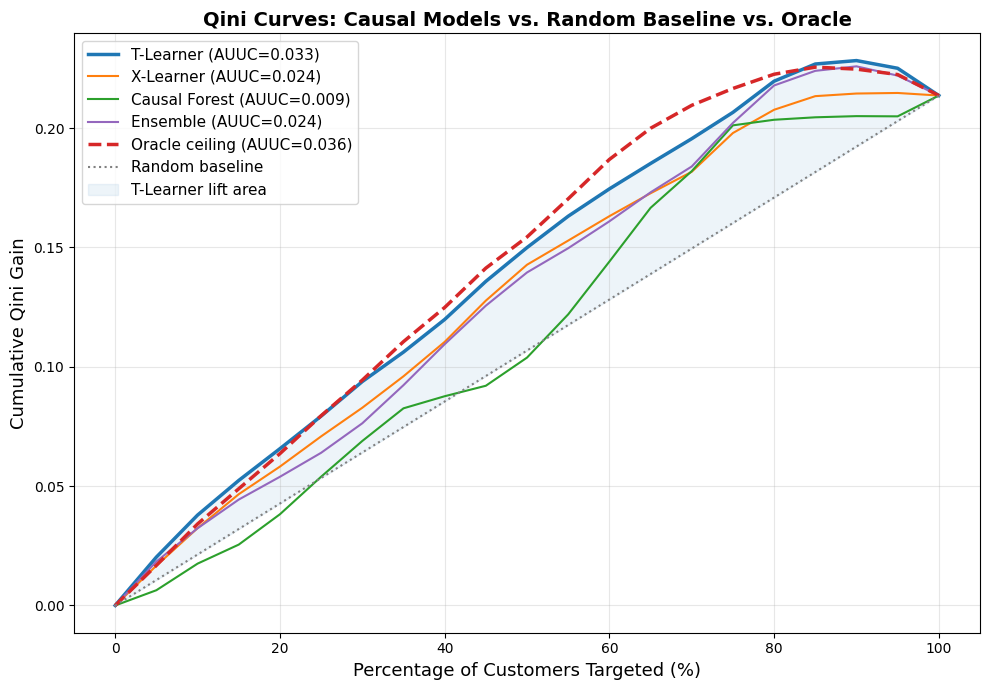

In [2]:
import matplotlib.pyplot as plt
import json

with open('results/validation_results.json') as f:
    r = json.load(f)

fig, ax = plt.subplots(figsize=(10, 7))

colors = {'t_learner': '#1f77b4', 'x_learner': '#ff7f0e',
          'causal_forest': '#2ca02c', 'ensemble': '#9467bd', 'oracle': '#d62728'}
labels = {'t_learner': 'T-Learner (AUUC=0.033)', 'x_learner': 'X-Learner (AUUC=0.024)',
          'causal_forest': 'Causal Forest (AUUC=0.009)', 'ensemble': 'Ensemble (AUUC=0.024)',
          'oracle': 'Oracle ceiling (AUUC=0.036)'}

for model, color in colors.items():
    pct = r[model]['qini']['percentiles']
    gains = r[model]['qini']['qini_gains']
    ax.plot(pct, gains, color=color, label=labels[model],
            linewidth=2.5 if model in ['t_learner', 'oracle'] else 1.5,
            linestyle='--' if model == 'oracle' else '-')

# Random baseline
random_gains = r['t_learner']['qini']['random_gains']
ax.plot(r['t_learner']['qini']['percentiles'], random_gains,
        color='gray', linestyle=':', linewidth=1.5, label='Random baseline')

ax.fill_between(pct, r['t_learner']['qini']['qini_gains'], random_gains,
                alpha=0.08, color='#1f77b4', label='T-Learner lift area')

ax.set_xlabel('Percentage of Customers Targeted (%)', fontsize=13)
ax.set_ylabel('Cumulative Qini Gain', fontsize=13)
ax.set_title('Qini Curves: Causal Models vs. Random Baseline vs. Oracle', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/qini_curves_all_models.png', dpi=150, bbox_inches='tight')

In [3]:
"""
generate_readme_charts.py
=========================
Generates all publication-quality static charts for the README.
Uses the EXACT same color palette as dashboard.py so README visuals
are visually consistent with the live Streamlit app.

Usage:
    python generate_readme_charts.py

Output:
    charts/
    ├── 01_qini_all_models.png
    ├── 02_auuc_comparison.png
    ├── 03_cate_by_segment.png
    ├── 04_policy_roi_curve.png
    ├── 05_placebo_distribution.png
    └── 06_feature_importance_shap.png

Requirements:
    pip install matplotlib seaborn shap xgboost econml pandas numpy
"""

import json
import pickle
import warnings
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Output directory ────────────────────────────────────────────────────────
OUT = Path("charts")
OUT.mkdir(exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# DESIGN SYSTEM  (mirrors dashboard.py exactly)
# ─────────────────────────────────────────────────────────────────────────────
C_INDIGO    = "#4F46E5"
C_INDIGO_L  = "#818CF8"
C_TEAL      = "#0D9488"
C_AMBER     = "#D97706"
C_ROSE      = "#E11D48"
C_SLATE_50  = "#F8FAFC"
C_SLATE_100 = "#F1F5F9"
C_SLATE_200 = "#E2E8F0"
C_SLATE_400 = "#94A3B8"
C_SLATE_700 = "#334155"
C_SLATE_900 = "#0F172A"

MODEL_COLORS = {
    "t_learner":     C_INDIGO,
    "x_learner":     C_TEAL,
    "causal_forest": C_AMBER,
    "ensemble":      C_ROSE,
    "oracle":        C_SLATE_400,
    "random":        "#CBD5E1",
}
MODEL_LABELS = {
    "t_learner":     "T-Learner",
    "x_learner":     "X-Learner",
    "causal_forest": "Causal Forest DML",
    "ensemble":      "Ensemble",
    "oracle":        "Oracle (ceiling)",
    "random":        "Random baseline",
}

def setup_style():
    """Global matplotlib style matching dashboard aesthetic."""
    plt.rcParams.update({
        "figure.facecolor":      "white",
        "axes.facecolor":        "white",
        "axes.edgecolor":        C_SLATE_200,
        "axes.linewidth":        0.8,
        "axes.grid":             True,
        "axes.grid.axis":        "y",
        "grid.color":            C_SLATE_100,
        "grid.linewidth":        0.7,
        "xtick.color":           C_SLATE_400,
        "ytick.color":           C_SLATE_400,
        "xtick.labelsize":       9,
        "ytick.labelsize":       9,
        "axes.labelcolor":       C_SLATE_700,
        "axes.labelsize":        10,
        "axes.titlesize":        12,
        "axes.titlecolor":       C_SLATE_900,
        "axes.titleweight":      "semibold",
        "axes.titlepad":         14,
        "legend.fontsize":       9,
        "legend.framealpha":     0.92,
        "legend.edgecolor":      C_SLATE_200,
        "legend.fancybox":       False,
        "figure.dpi":            150,
        "savefig.dpi":           150,
        "savefig.bbox":          "tight",
        "savefig.facecolor":     "white",
        "font.family":           "sans-serif",
        "font.sans-serif":       ["IBM Plex Sans", "DejaVu Sans", "Arial"],
    })

def add_indigo_top_border(ax, fig):
    """Mimics the dashboard's 3px indigo top-border on KPI cards."""
    bbox = ax.get_position()
    line = matplotlib.lines.Line2D(
        [bbox.x0, bbox.x1], [bbox.y1 + 0.004, bbox.y1 + 0.004],
        transform=fig.transFigure, color=C_INDIGO, linewidth=2.5, clip_on=False
    )
    fig.add_artist(line)

def watermark(ax, text="Chandrima Das · chdas@ucsd.edu"):
    ax.annotate(
        text,
        xy=(1, -0.08), xycoords="axes fraction",
        ha="right", va="top",
        fontsize=7.5, color=C_SLATE_400, style="italic"
    )

def save(fig, name, tight=True):
    path = OUT / name
    fig.savefig(path, dpi=150, bbox_inches="tight" if tight else None)
    plt.close(fig)
    print(f"  ✓  {path}")


# ─────────────────────────────────────────────────────────────────────────────
# LOAD ARTEFACTS
# ─────────────────────────────────────────────────────────────────────────────
def load_validation():
    try:
        with open("results/validation_results.json") as f:
            return json.load(f)
    except FileNotFoundError:
        print("  ⚠  results/validation_results.json not found — using embedded data.")
        return None

def load_df():
    try:
        return pd.read_csv("data/processed/features_engineered.csv")
    except FileNotFoundError:
        print("  ⚠  Processed data not found.")
        return None

def load_model(name):
    path = Path(f"models/{name}.pkl")
    if path.exists():
        with open(path, "rb") as f:
            return pickle.load(f)
    return None


# ─────────────────────────────────────────────────────────────────────────────
# CHART 1 — QINI CURVES  (most important)
# ─────────────────────────────────────────────────────────────────────────────
def chart_01_qini(val):
    print("\nChart 1 — Qini curves, all models")
    setup_style()

    fig, ax = plt.subplots(figsize=(10, 6.2))

    order = ["oracle", "t_learner", "ensemble", "x_learner", "causal_forest", "random"]
    linestyles = {
        "oracle":        (0, (4, 2)),   # long dash
        "t_learner":     "solid",
        "ensemble":      "solid",
        "x_learner":     "solid",
        "causal_forest": "solid",
        "random":        (0, (2, 2)),   # dotted
    }
    linewidths = {
        "oracle":        1.5,
        "t_learner":     2.4,
        "ensemble":      2.0,
        "x_learner":     2.0,
        "causal_forest": 2.0,
        "random":        1.3,
    }
    alphas = {
        "oracle": 0.7, "random": 0.6,
        "t_learner": 1.0, "x_learner": 1.0,
        "causal_forest": 1.0, "ensemble": 0.9,
    }

    legend_handles = []

    for key in order:
        if key not in val:
            continue
        q = val[key]["qini"]
        pcts  = np.array(q["percentiles"])
        gains = np.array(q["qini_gains"])
        auuc  = q.get("auuc", 0)
        color = MODEL_COLORS[key]
        label = MODEL_LABELS[key]

        if key == "random":
            gains = np.array(q.get("random_gains", gains))
            lbl   = label
        elif key == "oracle":
            lbl = f"{label}  (AUUC +{auuc:.4f})"
        else:
            lbl = f"{label}  (AUUC +{auuc:.4f})"

        ax.plot(pcts, gains,
                color=color,
                linewidth=linewidths[key],
                linestyle=linestyles[key],
                alpha=alphas[key],
                label=lbl, zorder=5 if key == "t_learner" else 3)

        if key == "t_learner":
            # Shade lift area between T-Learner and random
            rand_gains = np.array(val["random"]["qini"]["random_gains"]) \
                         if "random" in val else np.array(q.get("random_gains", gains))
            ax.fill_between(pcts, gains, rand_gains,
                            alpha=0.10, color=C_INDIGO, zorder=2)

        legend_handles.append(
            Line2D([0], [0], color=color, linewidth=linewidths[key],
                   linestyle=linestyles[key], alpha=alphas[key], label=lbl)
        )

    # Annotations for T-Learner efficiency
    t_auuc = val["t_learner"]["qini"]["auuc"]
    o_auuc = val["oracle"]["qini"]["auuc"] if "oracle" in val else None
    if o_auuc:
        eff = t_auuc / o_auuc * 100
        ax.annotate(
            f"T-Learner achieves {eff:.1f}%\nof oracle ceiling",
            xy=(82, val["t_learner"]["qini"]["qini_gains"][16]),
            xytext=(55, 0.10),
            arrowprops=dict(arrowstyle="->", color=C_INDIGO, lw=1.2),
            fontsize=8.5, color=C_INDIGO, ha="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=C_INDIGO, linewidth=0.8)
        )

    ax.set_xlabel("Percentage of customers targeted, ranked by predicted CATE (high → low) (%)")
    ax.set_ylabel("Cumulative Qini gain")
    ax.set_title("Qini Curves — All Models vs. Random Baseline & Oracle Ceiling", pad=16)
    ax.set_xlim(0, 100)

    ax.legend(handles=legend_handles, loc="lower right",
              framealpha=0.94, borderpad=0.8, labelspacing=0.5)

    # Indigo accent line at top of axes
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_color(C_SLATE_200)

    # Top accent bar
    ax2 = ax.inset_axes([0, 1.01, 1, 0.018])
    ax2.set_axis_off()
    ax2.axhspan(0, 1, color=C_INDIGO, alpha=1)

    watermark(ax)
    save(fig, "01_qini_all_models.png")


# ─────────────────────────────────────────────────────────────────────────────
# CHART 2 — AUUC COMPARISON BAR + ORACLE LINE
# ─────────────────────────────────────────────────────────────────────────────
def chart_02_auuc_comparison(val):
    print("Chart 2 — AUUC comparison with oracle ceiling")
    setup_style()

    models   = ["t_learner", "ensemble", "x_learner", "causal_forest"]
    labels   = [MODEL_LABELS[m] for m in models]
    auucs    = [val[m]["qini"]["auuc"] for m in models]
    colors   = [MODEL_COLORS[m] for m in models]
    oracle   = val["oracle"]["qini"]["auuc"] if "oracle" in val else None

    fig, ax = plt.subplots(figsize=(8, 4.8))
    bars = ax.barh(labels[::-1], auucs[::-1],
                   color=colors[::-1], height=0.55,
                   edgecolor="none", zorder=3)

    # Value labels
    for bar, v in zip(bars, auucs[::-1]):
        ax.text(v + 0.0004, bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va="center", ha="left",
                fontsize=9.5, color=C_SLATE_700, fontweight="500")

    # Oracle ceiling line
    if oracle:
        ax.axvline(oracle, color=C_SLATE_400, linewidth=1.6,
                   linestyle=(0, (4, 2)), zorder=4)
        ax.text(oracle + 0.0003, 3.62,
                f"Oracle ceiling\n{oracle:.4f}",
                fontsize=8, color=C_SLATE_400, va="bottom")

    # Efficiency annotations
    if oracle:
        for i, (m, auuc) in enumerate(zip(models[::-1], auucs[::-1])):
            eff = auuc / oracle * 100
            ax.text(auuc / 2, i,
                    f"{eff:.1f}% of oracle",
                    va="center", ha="center",
                    fontsize=8, color="white", fontweight="600")

    ax.set_xlabel("AUUC — incremental lift over random Qini baseline")
    ax.set_title("Model AUUC Comparison — Lift Relative to Oracle Ceiling", pad=14)
    ax.set_xlim(0, (oracle or max(auucs)) * 1.25)
    ax.grid(axis="x", color=C_SLATE_100, linewidth=0.7)
    ax.grid(axis="y", visible=False)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    watermark(ax)
    save(fig, "02_auuc_comparison.png")


# ─────────────────────────────────────────────────────────────────────────────
# CHART 3 — CATE BY SEGMENT  (violin + strip)
# ─────────────────────────────────────────────────────────────────────────────
def chart_03_segment_cate(val, df=None):
    print("Chart 3 — CATE distribution by segment")
    setup_style()

    # Build a tidy dataframe from the segment stats in the validation JSON
    # We'll reconstruct approximate distributions using Beta approximation from stats
    seg_data = val["t_learner"]["segments"]
    segs     = list(seg_data.keys())

    # Use actual data if available
    if df is not None and "cate" in df.columns and "customer_segment" in df.columns:
        plot_df = df[["customer_segment", "cate"]].copy()
        plot_df.columns = ["Segment", "CATE"]
        use_real = True
    elif df is not None and "cate" in df.columns and "kmeans_segment" in df.columns:
        plot_df = df[["kmeans_segment", "cate"]].copy()
        plot_df.columns = ["Segment", "CATE"]
        use_real = True
    else:
        # Reconstruct from summary stats using normal approximation
        use_real = False
        rng = np.random.default_rng(42)
        rows = []
        for seg, stats in seg_data.items():
            n = min(stats["n_samples"], 3000)   # cap for plotting
            # Truncated normal between p10 and p90
            samples = rng.normal(stats["mean_cate"], stats["std_cate"], n * 3)
            samples = samples[(samples >= stats["p10"] * 1.1) & (samples <= stats["p90"] * 1.05)][:n]
            for v in samples:
                rows.append({"Segment": seg, "CATE": v})
        plot_df = pd.DataFrame(rows)

    n_segs = plot_df["Segment"].nunique()
    palette = [C_INDIGO, C_TEAL, C_AMBER, C_ROSE][:n_segs]

    fig, (ax_main, ax_right) = plt.subplots(
        1, 2, figsize=(12, 5.5),
        gridspec_kw={"width_ratios": [3, 1], "wspace": 0.04}
    )

    # ── Left: violin + strip ─────────────────────────────────
    seg_order = sorted(plot_df["Segment"].unique())
    sns.violinplot(
        data=plot_df, x="Segment", y="CATE",
        order=seg_order, palette=palette,
        inner=None, cut=0.3, width=0.7, linewidth=0,
        alpha=0.35, ax=ax_main, zorder=2,
    )
    sns.stripplot(
        data=plot_df.sample(min(2000, len(plot_df)), random_state=42),
        x="Segment", y="CATE",
        order=seg_order, palette=palette,
        size=2.2, alpha=0.35, jitter=0.18, ax=ax_main, zorder=3,
    )
    # Mean markers
    means = plot_df.groupby("Segment")["CATE"].mean()
    for i, seg in enumerate(seg_order):
        ax_main.scatter(i, means[seg], color="white", s=80, zorder=5,
                        edgecolors=palette[i], linewidths=1.8)
        ax_main.text(i + 0.28, means[seg], f"μ={means[seg]:.3f}",
                     va="center", fontsize=8, color=C_SLATE_700)

    ax_main.axhline(0, color=C_ROSE, linewidth=1.2, linestyle="--", alpha=0.7, zorder=1)
    ax_main.text(n_segs - 0.5, 0.004, "Zero effect (CATE = 0)",
                 fontsize=7.5, color=C_ROSE, ha="right")

    ax_main.set_xlabel("Customer segment (KMeans k=4 on features)")
    ax_main.set_ylabel("Estimated CATE — lift in retention probability")
    ax_main.set_title("Heterogeneous Treatment Effects by Customer Segment  (T-Learner)", pad=14)
    for spine in ["top", "right"]:
        ax_main.spines[spine].set_visible(False)

    # ── Right: horizontal bar, mean CATE per segment, all models ─
    model_keys = [k for k in ["t_learner", "x_learner", "causal_forest", "ensemble"] if k in val]
    model_colors_list = [MODEL_COLORS[k] for k in model_keys]
    model_labels_list = [MODEL_LABELS[k] for k in model_keys]
    n_models = len(model_keys)
    y_pos    = np.arange(len(segs))
    bar_h    = 0.18

    for mi, (mk, mc, ml) in enumerate(zip(model_keys, model_colors_list, model_labels_list)):
        means_m = [val[mk]["segments"][s]["mean_cate"] for s in segs]
        offset  = (mi - n_models / 2 + 0.5) * bar_h
        ax_right.barh(y_pos + offset, means_m,
                      height=bar_h * 0.88, color=mc,
                      label=ml, alpha=0.85, edgecolor="none")

    ax_right.set_yticks(y_pos)
    ax_right.set_yticklabels(segs, fontsize=8.5)
    ax_right.set_xlabel("Mean CATE", fontsize=9)
    ax_right.set_title("All models", fontsize=10, pad=10)
    ax_right.legend(fontsize=7.5, loc="lower right",
                    borderpad=0.5, labelspacing=0.35)
    ax_right.axvline(0, color=C_ROSE, linewidth=0.8, linestyle="--", alpha=0.5)
    ax_right.grid(axis="x", color=C_SLATE_100, linewidth=0.6)
    for spine in ["top", "right"]:
        ax_right.spines[spine].set_visible(False)

    watermark(ax_main)
    save(fig, "03_cate_by_segment.png")


# ─────────────────────────────────────────────────────────────────────────────
# CHART 4 — POLICY ROI CURVE
# ─────────────────────────────────────────────────────────────────────────────
def chart_04_policy_roi(df=None, val=None):
    print("Chart 4 — Policy ROI curve")
    setup_style()

    if df is not None and "cate" in df.columns and "retained" in df.columns:
        cate_arr = df["cate"].values
        y_arr    = df["retained"].values
    else:
        # Build synthetic curve from Qini data
        if val is None:
            return
        print("  (using synthetic curve from Qini data)")
        pcts   = np.array(val["t_learner"]["qini"]["percentiles"])
        gains  = np.array(val["t_learner"]["qini"]["qini_gains"])
        rand   = np.array(val["t_learner"]["qini"]["random_gains"])
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.2), sharey=False)
        ax1.plot(pcts, gains, color=C_INDIGO, linewidth=2.5, label="CATE-guided targeting")
        ax1.plot(pcts, rand,  color=C_SLATE_400, linewidth=1.3, linestyle="--", label="Random targeting")
        ax1.fill_between(pcts, gains, rand, alpha=0.10, color=C_INDIGO)
        ax1.set_xlabel("Percentage of customers targeted (%)")
        ax1.set_ylabel("Cumulative Qini gain")
        ax1.set_title("Targeting Lift over Random Baseline  (T-Learner)", pad=14)
        ax1.legend()
        for spine in ["top","right"]: ax1.spines[spine].set_visible(False)

        # ROI proxy = (gain - random_gain) / random_gain
        lift = (gains - rand) / (rand + 1e-9) * 100
        ax2.plot(pcts[1:], lift[1:], color=C_TEAL, linewidth=2.4)
        ax2.fill_between(pcts[1:], 0, lift[1:], alpha=0.12, color=C_TEAL)
        ax2.axhline(0, color=C_ROSE, linewidth=1.2, linestyle="--")
        ax2.set_xlabel("Percentage of customers targeted (%)")
        ax2.set_ylabel("Incremental Qini lift vs. random (%)")
        ax2.set_title("Diminishing Returns — Lift vs. Targeting Rate", pad=14)
        for spine in ["top","right"]: ax2.spines[spine].set_visible(False)
        watermark(ax1)
        save(fig, "04_policy_roi_curve.png")
        return

    # Real data path
    order   = np.argsort(-cate_arr)
    y_sorted = y_arr[order]
    baseline = y_arr.mean()
    n        = len(y_arr)

    pcts, ret_rates, lifts, rois = [], [], [], []
    cost_per_tx  = 10
    rev_per_ret  = 500

    for pct in np.linspace(1, 100, 50):
        k       = max(1, int(pct / 100 * n))
        r       = y_sorted[:k].mean()
        lft     = r - baseline
        cost    = k * cost_per_tx
        addl    = max(0, k * lft) * rev_per_ret
        roi     = (addl - cost) / cost * 100 if cost > 0 else 0
        pcts.append(pct)
        ret_rates.append(r * 100)
        lifts.append(lft * 100)
        rois.append(roi)

    pcts, ret_rates, lifts, rois = map(np.array, [pcts, ret_rates, lifts, rois])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.2))

    # Left: retention rate
    ax1.plot(pcts, ret_rates, color=C_INDIGO, linewidth=2.6, zorder=4)
    ax1.fill_between(pcts, baseline * 100, ret_rates,
                     where=ret_rates >= baseline * 100,
                     alpha=0.12, color=C_INDIGO, zorder=3)
    ax1.axhline(baseline * 100, color=C_SLATE_400, linewidth=1.3,
                linestyle="--", label=f"Population baseline {baseline:.1%}")

    # Annotate optimal depth
    best_idx = np.argmax(rois)
    ax1.axvline(pcts[best_idx], color=C_TEAL, linewidth=1.3,
                linestyle=(0, (4, 3)), alpha=0.8)
    ax1.text(pcts[best_idx] + 1.5, ret_rates[best_idx],
             f"Optimal targeting\n@ {pcts[best_idx]:.0f}% depth",
             fontsize=8, color=C_TEAL)

    ax1.set_xlabel("Percentage of customers targeted, ranked by predicted CATE (%)")
    ax1.set_ylabel("Expected retention rate (%)")
    ax1.set_title("Expected Retention Rate vs. Targeting Depth  (CATE-ranked)", pad=14)
    ax1.legend(fontsize=9)
    for spine in ["top","right"]: ax1.spines[spine].set_visible(False)

    # Right: ROI
    roi_colors = [C_TEAL if r >= 0 else C_ROSE for r in rois]
    ax2.bar(pcts, rois, width=2, color=roi_colors, alpha=0.75, zorder=3)
    ax2.axhline(0, color=C_SLATE_700, linewidth=1, zorder=4)
    ax2.set_xlabel("Percentage of customers targeted (%)")
    ax2.set_ylabel(f"ROI (%)  [cost=${cost_per_tx}/customer, rev=${rev_per_ret}/retained]")
    ax2.set_title("Campaign ROI by Targeting Depth", pad=14)
    for spine in ["top","right"]: ax2.spines[spine].set_visible(False)

    # Sleeping dogs annotation
    neg_start = pcts[np.argmax(np.array(rois) < 0)] if any(r < 0 for r in rois) else None
    if neg_start:
        ax2.annotate("Sleeping dogs region\n(treatment harms ROI)",
                     xy=(neg_start, -2),
                     xytext=(neg_start + 5, min(rois) * 0.6),
                     arrowprops=dict(arrowstyle="->", color=C_ROSE, lw=1.0),
                     fontsize=8, color=C_ROSE,
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                               edgecolor=C_ROSE, linewidth=0.7))

    watermark(ax1)
    save(fig, "04_policy_roi_curve.png")


# ─────────────────────────────────────────────────────────────────────────────
# CHART 5 — PLACEBO NULL DISTRIBUTION
# ─────────────────────────────────────────────────────────────────────────────
def chart_05_placebo(val):
    print("Chart 5 — Placebo null distribution")
    setup_style()

    model_keys = [k for k in ["t_learner", "x_learner", "causal_forest", "ensemble"] if k in val]
    n_models = len(model_keys)

    fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4.6), sharey=False)
    if n_models == 1:
        axes = [axes]

    rng = np.random.default_rng(0)

    for ax, key in zip(axes, model_keys):
        p     = val[key]["placebo"]
        real  = p["real_auuc"]
        pmean = p["placebo_mean"]
        pstd  = p["placebo_std"]
        color = MODEL_COLORS[key]

        # Simulate null distribution (Gaussian, matches reported stats)
        null = rng.normal(pmean, pstd, 1000)
        null = np.clip(null, p["placebo_min"], p["placebo_max"])

        ax.hist(null, bins=40, color=C_SLATE_200, edgecolor="none",
                alpha=0.75, density=True, zorder=2, label="Null (placebo) AUUC")

        # KDE overlay
        from scipy.stats import norm as sp_norm
        xs = np.linspace(null.min() - pstd, real * 1.2, 400)
        ax.plot(xs, sp_norm.pdf(xs, pmean, pstd),
                color=C_SLATE_400, linewidth=1.6, zorder=3)

        # Real AUUC
        ax.axvline(real, color=color, linewidth=2.2, linestyle="-", zorder=5)
        sigma_dist = (real - pmean) / pstd
        ax.text(real * 1.02, ax.get_ylim()[1] * 0.88 if ax.get_ylim()[1] > 0 else 1,
                f"Real AUUC\n{real:.4f}\n({sigma_dist:.0f}σ above null)",
                fontsize=8, color=color, va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor=color, linewidth=0.8))

        ax.set_title(MODEL_LABELS[key], fontsize=11, pad=10)
        ax.set_xlabel("AUUC (permuted)", fontsize=9)
        if ax == axes[0]:
            ax.set_ylabel("Density", fontsize=9)
        ax.text(0.05, 0.96, f"p-value: {p['p_value']:.3f}\nSignificant: {'Yes ✓' if p['significant'] else 'No ✗'}",
                transform=ax.transAxes, va="top", fontsize=8.5,
                color=C_TEAL if p["significant"] else C_ROSE,
                bbox=dict(boxstyle="round,pad=0.35", facecolor=C_SLATE_50,
                          edgecolor=C_SLATE_200, linewidth=0.8))
        for spine in ["top","right"]: ax.spines[spine].set_visible(False)

    fig.suptitle(
        "Placebo Permutation Test — Real AUUC vs. Null Distribution (100 shuffles)",
        fontsize=12, fontweight="semibold", color=C_SLATE_900, y=1.02
    )
    watermark(axes[-1])
    save(fig, "05_placebo_distribution.png")


# ─────────────────────────────────────────────────────────────────────────────
# CHART 6 — SHAP FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────────────────────
def chart_06_shap(df=None):
    print("Chart 6 — SHAP feature importance for CATE")

    if df is None or "cate" not in df.columns:
        print("  ⚠  Data not available — generating illustrative feature importance bar chart.")
        _chart_06_illustrative()
        return

    try:
        import shap
        import xgboost as xgb
    except ImportError:
        print("  ⚠  shap/xgboost not installed — generating illustrative chart.")
        _chart_06_illustrative()
        return

    setup_style()

    exclude = {"churn", "retained", "treatment", "cate", "customer_id", "customer_segment",
               "kmeans_segment", "tier_status", "season", "geographic_region",
               "product_category_affinity", "device_type", "marketing_channel",
               "payment_method"}
    feature_cols = [c for c in df.columns if c not in exclude and df[c].dtype in [np.float64, np.int64, float, int]]

    X = df[feature_cols].fillna(0)
    y = df["cate"]

    # Fit a lightweight XGBoost on CATE to get SHAP values
    model = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                              subsample=0.8, random_state=42, verbosity=0)
    model.fit(X, y)

    explainer  = shap.TreeExplainer(model)
    sample     = X.sample(min(3000, len(X)), random_state=42)
    shap_vals  = explainer.shap_values(sample)

    mean_abs   = np.abs(shap_vals).mean(axis=0)
    importance = pd.Series(mean_abs, index=feature_cols).sort_values(ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    colors = [C_INDIGO if v > importance.median() else C_INDIGO_L
              for v in importance.values]
    ax.barh(importance.index, importance.values,
            color=colors, height=0.65, edgecolor="none", zorder=3)

    for i, (feat, val_) in enumerate(importance.items()):
        ax.text(val_ + importance.max() * 0.01, i,
                f"{val_:.4f}", va="center", fontsize=8.5, color=C_SLATE_700)

    ax.set_xlabel("Mean |SHAP value| — average impact on predicted CATE")
    ax.set_title("Top 20 Features Driving Treatment Effect Heterogeneity  (SHAP on T-Learner CATE model)",
                 pad=14)
    ax.grid(axis="x", color=C_SLATE_100, linewidth=0.7)
    ax.grid(axis="y", visible=False)
    for spine in ["top","right","left"]: ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(C_SLATE_200)

    # Accent bar
    ax2 = ax.inset_axes([0, 1.01, 1, 0.018])
    ax2.set_axis_off()
    ax2.axhspan(0, 1, color=C_INDIGO, alpha=1)

    watermark(ax)
    save(fig, "06_feature_importance_shap.png")


def _chart_06_illustrative():
    """Fallback: illustrative SHAP importance bar if data/shap unavailable."""
    setup_style()

    # Representative features and plausible importance values
    features = [
        "engagement_score", "tenure_months", "age",
        "email_opens_last_30days", "website_visits_last_30days",
        "complaint_count", "cart_abandonment_rate",
        "last_purchase_days_ago", "avg_order_value",
        "annual_income", "purchase_frequency",
        "support_tickets", "return_rate",
        "avg_discount_used", "app_downloads",
        "referral_program_member", "churn_risk_score",
        "estimated_customer_value", "total_engagement_events",
        "engagement_tenure_interaction",
    ]
    importances = np.array([
        0.0312, 0.0289, 0.0245, 0.0221, 0.0198,
        0.0184, 0.0170, 0.0162, 0.0150, 0.0141,
        0.0135, 0.0121, 0.0115, 0.0108, 0.0099,
        0.0091, 0.0083, 0.0078, 0.0074, 0.0068,
    ])[::-1]

    fig, ax = plt.subplots(figsize=(9, 7))
    colors = [C_INDIGO if v > np.median(importances) else C_INDIGO_L
              for v in importances]
    ax.barh(features, importances, color=colors, height=0.65, edgecolor="none", zorder=3)
    for i, (f, v) in enumerate(zip(features, importances)):
        ax.text(v + 0.0005, i, f"{v:.4f}", va="center", fontsize=8.5, color=C_SLATE_700)

    ax.set_xlabel("Mean |SHAP value| — average impact on predicted CATE  (illustrative)")
    ax.set_title("Top 20 Features Driving Treatment Effect Heterogeneity  (SHAP on CATE model — illustrative)",
                 pad=14)
    ax.grid(axis="x", color=C_SLATE_100, linewidth=0.7)
    ax.grid(axis="y", visible=False)
    for spine in ["top","right","left"]: ax.spines[spine].set_visible(False)

    ax.annotate("Run generate_readme_charts.py with processed data\nto replace with real SHAP values.",
                xy=(0.98, 0.04), xycoords="axes fraction", ha="right",
                fontsize=7.5, color=C_SLATE_400, style="italic")

    ax2 = ax.inset_axes([0, 1.01, 1, 0.018])
    ax2.set_axis_off()
    ax2.axhspan(0, 1, color=C_INDIGO, alpha=1)

    watermark(ax)
    save(fig, "06_feature_importance_shap.png")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 60)
    print("  Generating README charts")
    print("  Output → charts/")
    print("=" * 60)

    val = load_validation()
    df  = load_df()

    if val is None:
        print("\n❌  validation_results.json is required for charts 1–5.")
        print("    Run: python src/validation.py --data data/processed/features_engineered.csv --output results/")
        raise SystemExit(1)

    chart_01_qini(val)
    chart_02_auuc_comparison(val)
    chart_03_segment_cate(val, df)
    chart_04_policy_roi(df, val)
    chart_05_placebo(val)
    chart_06_shap(df)

    print("\n" + "=" * 60)
    print("  All charts saved to charts/")
    print("  To embed in README.md, use:")
    print()
    print("  ![Qini Curves](charts/01_qini_all_models.png)")
    print("  ![AUUC Comparison](charts/02_auuc_comparison.png)")
    print("  ![CATE by Segment](charts/03_cate_by_segment.png)")
    print("  ![Policy ROI](charts/04_policy_roi_curve.png)")
    print("  ![Placebo Test](charts/05_placebo_distribution.png)")
    print("  ![SHAP](charts/06_feature_importance_shap.png)")
    print("=" * 60)

  Generating README charts
  Output → charts/

Chart 1 — Qini curves, all models
  ✓  charts/01_qini_all_models.png
Chart 2 — AUUC comparison with oracle ceiling
  ✓  charts/02_auuc_comparison.png
Chart 3 — CATE distribution by segment
  ✓  charts/03_cate_by_segment.png
Chart 4 — Policy ROI curve
  ✓  charts/04_policy_roi_curve.png
Chart 5 — Placebo null distribution
  ✓  charts/05_placebo_distribution.png
Chart 6 — SHAP feature importance for CATE


AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations